# Procedures:

## 9.1 Introduction to Matplotlib
Setting up we started by importing matplotlib.pyplot and pandas. We loaded two datasets: Facebook stock prices for 2018 and earthquake data from a specific time period. This is the usual setup before plotting.

First line plot we used plt.plot() to draw a line chart of Facebook's opening price over time. We had to call plt.show() to actually see it. The plot showed how the stock price moved up and down throughout the year.

Using %matplotlib inline then we learned about the magic command %matplotlib inline. Putting this at the top of the notebook means we don't have to type plt.show() every time – the plot just appears automatically below the code cell. It's super convenient.

Scatter plot with style string
We tried making a scatter plot by passing 'ro' as the style – that stands for red circles. We plotted the high vs low prices for just the first 20 days of Facebook data. The points were all clustered together, which makes sense because high and low prices on the same day are usually close.

Understanding Figure and Axes
We learned that a "Figure" is like the blank canvas, and "Axes" are the actual plots we draw on. One Figure can hold multiple Axes. We created an empty Figure just to see what it looks like.

Creating subplots with plt.subplots()
We made a figure with two side-by-side subplots. On the left we plotted opening price, on the right closing price. This is great for comparing two things without switching between separate graphs.

Picture‑in‑picture with add_axes()
We used add_axes() to put a smaller plot inside a bigger one. The main plot showed opening price, and the inset showed closing price zoomed in. It's like having a magnifying glass for a specific part of the data.

Complex layouts with gridspec
gridspec let us create a more custom layout – a 3×3 grid where one subplot took up two rows, and another stretched across the whole bottom. We plotted different stock columns in each to see them all at once.

Saving plots
We used fig.savefig() to save the last plot as an image file. Handy for including in reports or sharing.

Cleaning up with plt.close()
We closed all open figures with plt.close('all') to free up memory. It's a good habit, especially when you're making lots of plots.

Changing default settings with rcParams
We peeked at the default figure size and changed it using rcParams. Then we reset everything back to normal with rcdefaults(). This showed us we can tweak the global style if we want, though usually we set size per plot.

## 9.2 Plotting with Pandas
Basic line plot with pandas
We used the DataFrame's .plot() method to make the same line plot of opening price. It's much simpler – just one line of code. We added a title and removed the legend because it wasn't needed.

Plotting multiple lines
By giving a list of column names, we plotted open, high, low, and close all on the same graph. We used different line styles to tell them apart. It was interesting to see how they move together.

Subplots automatically with pandas
Passing subplots=True to .plot() made pandas create separate little plots for each numeric column, arranged in a grid. We set the layout to 3 rows and 2 columns. This is a quick way to get an overview of all your variables.

Scatter plot
We created a new column max_abs_change (high minus low) and made a scatter plot of that against volume. There didn't seem to be a clear pattern – the points were all over the place.

Scatter plot with log scale
Because volume values are huge compared to price changes, we added logx=True to use a logarithmic scale on the x‑axis. That spread the points out a bit and made it easier to see what's going on.

Adding transparency with alpha
We set alpha=0.25 to make the points semi‑transparent. This helped see where lots of points overlapped – darker areas meant more data.

Hexbin plot
Hexbin plots are another way to handle overplotting. The plot is divided into hexagons, and the color tells you how many points fall in each hexagon. We used a gray colormap and adjusted gridsize to control the number of hexagons.

Correlation heatmap
Pandas doesn't have a built‑in heatmap, but we used matshow() from matplotlib to show the correlation matrix of the stock data. The colors ranged from red (positive correlation) to blue (negative). Not surprisingly, open, high, low, and close were all highly correlated.

Histogram of volume
We made a histogram of trading volume. It was skewed to the right – most days had lower volume, with a few days of very high volume.

Overlapping histograms for earthquake magTypes
We looped through each unique magnitude type in the earthquake data and plotted a histogram for each, using alpha to make them see‑through. This let us compare the distributions of different magnitude scales.

Kernel Density Estimation (KDE)
KDE gives a smooth curve of the distribution. We plotted the KDE of Facebook's high price – it showed a peak around 180‑200 dollars.

Histogram + KDE together
We put a histogram and a KDE on the same plot. The histogram gave the raw counts, and the KDE smoothed it out. Good for understanding the shape of the data.

ECDF (Empirical Cumulative Distribution Function)
Using statsmodels, we plotted the ECDF of earthquake magnitudes for the 'ml' type. The line shows the proportion of earthquakes with magnitude less than or equal to a given value. We saw that about 98% of 'ml' earthquakes had magnitude 3 or less.

Box plot of OHLC
A box plot of open, high, low, and close showed the median, quartiles, and outliers. All four had similar medians, but we could see the spread.

Grouped box plots by volume
We split volume into three bins (low, med, high) and made box plots of the price columns for each bin. This helped us see if prices behave differently on high‑volume days.

Bar chart of monthly volume
We resampled the data by month and summed the volume, then made a bar chart. Some months had noticeably higher trading volume.

Horizontal bar chart of top earthquake places
We took the top 15 places with the most earthquakes and plotted them as horizontal bars. California and Alaska were at the top. Horizontal bars are great when the category names are long.

Stacked bar chart
We created a pivot table of magnitude bins vs. magType and made a stacked bar chart. Each bar showed the total earthquakes for that magnitude, split by magType.

Normalized stacked bar
We divided each row by its total so that all bars added up to 1 (100%). This made it easier to compare the proportion of each magType across different magnitude ranges.

## 9.3 Pandas Plotting Subpackage
Scatter matrix
scatter_matrix from pandas.plotting creates a grid of scatter plots for every pair of columns. The diagonal can be histograms or KDE. It's a quick way to see relationships between many variables at once.

Lag plot
A lag plot plots a variable against itself shifted by a certain number of days. For random data, the points look like a cloud. For stock prices, they line up along the diagonal – strong autocorrelation. We tried lag 1 and lag 5.

Autocorrelation plot
autocorrelation_plot shows the correlation of a series with itself at different lags. The blue line is the correlation, and the shaded region shows what's probably just noise. Stock prices stayed above the noise for many lags, meaning past prices are related to future prices.

Bootstrap plot
bootstrap_plot takes many random samples (with replacement) from the data and plots the distribution of the mean, median, and midrange. It gives you an idea of how stable those statistics are. For Facebook volume, the mean was around 25 million, and the bootstrap samples showed some variation around that.

## 9.1

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

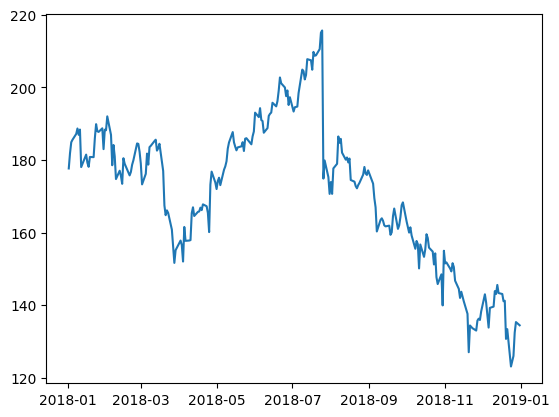

In [2]:
fb = pd.read_csv(
    '/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open )
plt.show()

## 9.2

## 9.3